# **Customer Churn Prediction to Improve Customer Retention Strategy**
Oleh: Deasy Rahmawahida Alwani

# **Overview**

Dalam kasus ini, dilakukan analisis **customer churn prediction** menggunakan pendekatan **supervised machine learning classification** pada dataset pelanggan telekomunikasi (`churn.csv`).
Customer churn merupakan kondisi di mana pelanggan memutuskan untuk berhenti menggunakan layanan perusahaan. Masalah ini menjadi krusial karena pada prakteknya, mempertahankan pelanggan lama umumnya lebih efisien dibandingkan mengakuisisi pelanggan baru, sehingga perusahaan perlu mengambil langkah yang tepat untuk mengatasinya.

Tujuan utama dari analisis ini adalah untuk membangun model prediksi yang mampu mengidentifikasi pelanggan yang berpotensi melakukan churn, sehingga perusahaan dapat menyusun strategi retensi pelanggan yang lebih proaktif dan tepat sasaran.

**Dataset:** `churn.csv`

Dataset ini berisi informasi karakteristik pelanggan, layanan yang digunakan, serta detail pembayaran pelanggan perusahaan telekomunikasi.
<br>

| **Column Name**    | **Description**                                                  |
| ------------------ | ---------------------------------------------------------------- |
| `customerID`       | ID unik pelanggan                                                |
| `gender`           | Jenis kelamin pelanggan                                          |
| `SeniorCitizen`    | Status lansia (1 = Yes, 0 = No)                                  |
| `Partner`          | Status memiliki pasangan                                         |
| `Dependents`       | Status memiliki tanggungan                                       |
| `tenure`           | Lama berlangganan (dalam bulan)                                  |
| `PhoneService`     | Status penggunaan layanan telepon                                |
| `MultipleLines`    | Status penggunaan beberapa jalur telepon                         |
| `InternetService`  | Jenis layanan internet                                           |
| `OnlineSecurity`   | Status layanan keamanan online                                   |
| `OnlineBackup`     | Status layanan backup online                                     |
| `DeviceProtection` | Status perlindungan perangkat                                    |
| `TechSupport`      | Status layanan dukungan teknis                                   |
| `StreamingTV`      | Status layanan streaming TV                                      |
| `StreamingMovies`  | Status layanan streaming film                                    |
| `Contract`         | Jenis kontrak pelanggan                                          |
| `PaperlessBilling` | Status tagihan tanpa kertas                                      |
| `PaymentMethod`    | Metode pembayaran                                                |
| `MonthlyCharges`   | Biaya bulanan pelanggan                                          |
| `TotalCharges`     | Total biaya yang telah dibayarkan pelanggan                      |
| `Churn`            | Target variable (Yes = pelanggan churn, No = pelanggan bertahan) |


# **1. Persiapan Data**

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import math

# Feature Engineering
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Regression
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression

# Clustering
from sklearn.cluster import KMeans

# Cross-Validation
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

# Evaluation metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.metrics import silhouette_score

pd.options.display.float_format = '{:.3f}'.format

# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Mengatur style plot agar terlihat lebih menarik
sns.set_style("whitegrid")

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


## Load dataset

In [ ]:
# Load dataset

churn_data = pd.read_csv('/content/churn.csv')
print("✅ Dataset berhasil dimuat!")

churn_data.head()


✅ Dataset berhasil dimuat!


,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.000,NaN,No,1.000,Month-to-month,Yes,Electronic check,29.850,29.850,No
1,5575-GNVDE,Male,0.000,No,No,34.000,One year,No,Mailed check,56.950,1889.500,No
2,3668-QPYBK,Male,0.000,No,No,2.000,Month-to-month,Yes,Mailed check,53.850,108.150,Yes
3,7795-CFOCW,Male,0.000,No,No,45.000,One year,No,Bank transfer (automatic),42.300,1840.750,No
4,9237-HQITU,Female,0.000,No,No,2.000,Month-to-month,Yes,Electronic check,70.700,151.650,Yes


In [ ]:
# BASIC INFORMATION
churn_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7046 entries, 0 to 7045
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7037 non-null   object 
 1   Gender            7030 non-null   object 
 2   SeniorCitizen     7034 non-null   float64
 3   Partner           7030 non-null   object 
 4   Dependents        7027 non-null   object 
 5   Tenure            7029 non-null   float64
 6   Contract          7033 non-null   object 
 7   PaperlessBilling  7033 non-null   object 
 8   PaymentMethod     7035 non-null   object 
 9   MonthlyCharges    7036 non-null   float64
 10  TotalCharges      7046 non-null   float64
 11  Churn             7046 non-null   object 
dtypes: float64(4), object(8)
memory usage: 660.7+ KB


In [ ]:
# Mencetak header dengan garis pembatas untuk bagian statistik numerik
print("="*60)
# Mencetak judul bagian statistik deskriptif dengan emoji
print("📊 STATISTIK DESKRIPTIF VARIABEL NUMERIK")
# Mencetak garis pembatas penutup header
print("="*60)

# Pilih hanya kolom numerik
# Memfilter hanya kolom yang bertipe numerik (int, float) dan mengkonversi ke list
numeric_cols = churn_data.select_dtypes(include=[np.number]).columns.tolist()
# Mencetak daftar nama kolom numerik yang tersedia
print(f"Variabel numerik yang tersedia: {numeric_cols}")

# Menampilkan statistik deskriptif (mean, std, min, max, quartiles) untuk semua kolom numerik
display(churn_data[numeric_cols].describe())

# Mencetak baris kosong dan garis pembatas untuk bagian kategorikal
print("\n" + "="*60)
# Mencetak judul bagian informasi variabel kategorikal
print("📊 INFORMASI VARIABEL KATEGORIKAL")
# Mencetak garis pembatas penutup header
print("="*60)

# Pilih kolom kategorikal
# Memfilter hanya kolom yang bertipe object (string/kategorikal) dan mengkonversi ke list
categorical_cols = churn_data.select_dtypes(include=['object']).columns.tolist()
# Mencetak daftar nama kolom kategorikal yang tersedia
print(f"Variabel kategorikal: {categorical_cols}")

# Melakukan iterasi untuk 3 kolom kategorikal pertama saja untuk menghindari output yang terlalu panjang
for col in categorical_cols:
    # Mencetak nama kolom dengan huruf kapital dan format yang rapi
    print(f"\n{col.upper()}:")
    # Mencetak jumlah nilai unique dalam kolom tersebut
    print(f"  Unique values: {churn_data[col].nunique()}")
    # Memeriksa apakah jumlah nilai unique kurang dari atau sama dengan 10
    if churn_data[col].nunique() <= 10:
        # Jika sedikit, tampilkan semua nilai unique yang ada
        print(f"  Values: {list(churn_data[col].unique())}")
    else:
        # Jika banyak, hanya tampilkan 5 nilai teratas berdasarkan frekuensi
        print(f"  Top 5 values: {list(churn_data[col].value_counts().head().index)}")

📊 STATISTIK DESKRIPTIF VARIABEL NUMERIK
Variabel numerik yang tersedia: ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,7034.000,7029.000,7036.000,7046.000
mean,0.162,32.412,64.800,2281.922
std,0.369,24.547,30.071,2265.653
min,0.000,1.000,18.250,18.800
25%,0.000,9.000,35.650,401.350
50%,0.000,29.000,70.350,1397.100
75%,0.000,55.000,89.850,3791.000
max,1.000,72.000,118.750,8684.800



📊 INFORMASI VARIABEL KATEGORIKAL
Variabel kategorikal: ['customerID', 'Gender', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

CUSTOMERID:
  Unique values: 7023
  Top 5 values: ['3604-WLABM', '5067-WJEUN', '2342-CKIAO', '5233-GEEAX', '2905-KFQUV']

GENDER:
  Unique values: 2
  Values: ['Female', 'Male', nan]

PARTNER:
  Unique values: 2
  Values: [nan, 'No', 'Yes']

DEPENDENTS:
  Unique values: 2
  Values: ['No', 'Yes', nan]

CONTRACT:
  Unique values: 3
  Values: ['Month-to-month', 'One year', 'Two year', nan]

PAPERLESSBILLING:
  Unique values: 2
  Values: ['Yes', 'No', nan]

PAYMENTMETHOD:
  Unique values: 4
  Values: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)', nan]

CHURN:
  Unique values: 2
  Values: ['No', 'Yes']


In [ ]:
# Mengubah customerID menjadi index

churn_data.dropna(subset='customerID', inplace=True)

churn_data.set_index('customerID', inplace=True)

churn_data.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,
7590-VHVEG,Female,0.000,NaN,No,1.000,Month-to-month,Yes,Electronic check,29.850,29.850,No
5575-GNVDE,Male,0.000,No,No,34.000,One year,No,Mailed check,56.950,1889.500,No
3668-QPYBK,Male,0.000,No,No,2.000,Month-to-month,Yes,Mailed check,53.850,108.150,Yes
7795-CFOCW,Male,0.000,No,No,45.000,One year,No,Bank transfer (automatic),42.300,1840.750,No
9237-HQITU,Female,0.000,No,No,2.000,Month-to-month,Yes,Electronic check,70.700,151.650,Yes


## Handling Data Duplikat

In [ ]:
# Mengidentifikasi data duplikat
a = len(churn_data)
b = len(churn_data.drop_duplicates())
print("Jumlah data duplikat: ", a-b)

Jumlah data duplikat:  36


In [ ]:
# Menghapus data duplikat
churn_data = churn_data.drop_duplicates()

# Cek ulang
print("Jumlah data setelah drop duplicate:", len(churn_data))


Jumlah data setelah drop duplicate: 7001


Handling data duplikat telah dilaksanakan. Sedangkan untuk "Handling Missing Value" akan dilakukan setelah pembagian dataset.

## Mapping Target Variable

In [ ]:
churn_data.value_counts('Churn')

,count
Churn,
No,5146
Yes,1855


In [ ]:
# Map the target variable
churn_data.loc[:, 'Churn'] = churn_data['Churn'].map({'No': 0, 'Yes': 1})

churn_data.value_counts('Churn')

,count
Churn,
0,5146
1,1855


In [ ]:
churn_data['Churn'] = churn_data['Churn'].astype(int)


In [ ]:
churn_data['Churn'].dtype


dtype('int64')

# **2.	Pembagian Dataset**

In [ ]:
# target
y = churn_data[['Churn']]

# feature
X = churn_data.drop(columns='Churn', axis = 1).copy()

In [ ]:
# train-val-test split

# First splitting: pretrain and test
X_churn_pretrain, X_churn_test, y_churn_pretrain, y_churn_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Second splitting: train and validation
X_churn_train, X_churn_validation, y_churn_train, y_churn_validation = train_test_split(X_churn_pretrain, y_churn_pretrain, test_size=0.20, random_state=42)

X_churn_pretrain.shape, X_churn_train.shape, X_churn_validation.shape, X_churn_test.shape, y_churn_pretrain.shape, y_churn_train.shape, y_churn_validation.shape, y_churn_test.shape

((5600, 10),
 (4480, 10),
 (1120, 10),
 (1401, 10),
 (5600, 1),
 (4480, 1),
 (1120, 1),
 (1401, 1))

In [ ]:
X_churn_train.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
customerID,,,,,,,,,,
7542-CYDDM,Male,0.000,No,No,18.000,Month-to-month,No,Mailed check,20.050,358.500
4250-FDVOU,Female,0.000,No,No,6.000,Month-to-month,No,Electronic check,56.250,389.100
0617-FHSGK,Male,0.000,No,Yes,49.000,Month-to-month,No,Credit card (automatic),75.200,3678.300
3982-DQLUS,Male,1.000,Yes,Yes,65.000,Month-to-month,Yes,Electronic check,85.750,5688.450
0899-LIIBW,Male,0.000,Yes,No,34.000,Month-to-month,No,Electronic check,100.850,3527.300


Berdasarkan proses pembagian tersebut, diperoleh ukuran dataset sebagai berikut:

- Pretrain set : 5.600 data (80%)

- Training set : 4.480 data (64%)

- Validation set : 1.120 data (16%)

- Testing set : 1.401 data (20%)

Pembagian ini menghasilkan proporsi akhir sebesar 64% training, 16% validation, dan 20% testing, yang dinilai cukup seimbang dan representatif untuk membangun serta mengevaluasi model machine learning pada dataset churn.

## Handling Missing Value

Handling Missing value dilakukan setelah data split untuk mencegah data leakage dan menjaga evaluasi model tetap objektif.

###*Identifikasi Kolom Numerik & Kategorikal*

In [ ]:
num_cols = X_churn_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_churn_train.select_dtypes(include='object').columns

print(f"  Kolom Numerik: {list(num_cols)}")
print(f"  Kolom Kategorikal: {list(cat_cols)}")


  Kolom Numerik: ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']
  Kolom Kategorikal: ['Gender', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod']


###*Median Kolom Numerik pada data Train*

In [ ]:
num_median = X_churn_train[num_cols].median()
num_median

,0
SeniorCitizen,0.000
Tenure,29.000
MonthlyCharges,70.450
TotalCharges,1389.475


###*Mode Kolom Kategorikal pada data Train*

In [ ]:
cat_mode = X_churn_train[cat_cols].mode().iloc[0]
cat_mode

,0
Gender,Male
Partner,No
Dependents,No
Contract,Month-to-month
PaperlessBilling,Yes
PaymentMethod,Electronic check


###*Handling Missing Value dengan Imputasi (Kolom Numerik)*

In [ ]:
X_churn_train[num_cols] = X_churn_train[num_cols].fillna(num_median)
X_churn_validation[num_cols] = X_churn_validation[num_cols].fillna(num_median)
X_churn_test[num_cols] = X_churn_test[num_cols].fillna(num_median)


###*Handling Missing Value dengan Imputasi (Kolom Kategorikal)*

In [ ]:
X_churn_train[cat_cols] = X_churn_train[cat_cols].fillna(cat_mode)
X_churn_validation[cat_cols] = X_churn_validation[cat_cols].fillna(cat_mode)
X_churn_test[cat_cols] = X_churn_test[cat_cols].fillna(cat_mode)


###*Verifikasi Handling Missing Value*

In [ ]:
X_churn_train.isna().sum()

,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
Contract,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,0


In [ ]:
X_churn_validation.isna().sum()

,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
Contract,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,0


In [ ]:
X_churn_test.isna().sum()

,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
Contract,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,0


##EDA

In [ ]:
df_train = pd.concat([X_churn_train, y_churn_train], axis = 1)

df_train['Churn'] = df_train['Churn'].astype('str')

df_train.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,
7542-CYDDM,Male,0.000,No,No,18.000,Month-to-month,No,Mailed check,20.050,358.500,0
4250-FDVOU,Female,0.000,No,No,6.000,Month-to-month,No,Electronic check,56.250,389.100,1
0617-FHSGK,Male,0.000,No,Yes,49.000,Month-to-month,No,Credit card (automatic),75.200,3678.300,1
3982-DQLUS,Male,1.000,Yes,Yes,65.000,Month-to-month,Yes,Electronic check,85.750,5688.450,0
0899-LIIBW,Male,0.000,Yes,No,34.000,Month-to-month,No,Electronic check,100.850,3527.300,0


In [ ]:
df_train.value_counts('Churn', normalize = True)

,proportion
Churn,
0,0.739
1,0.261


 VARIABLES DISTRIBUTION ANALYSIS (NUMERICAL FEATURES)


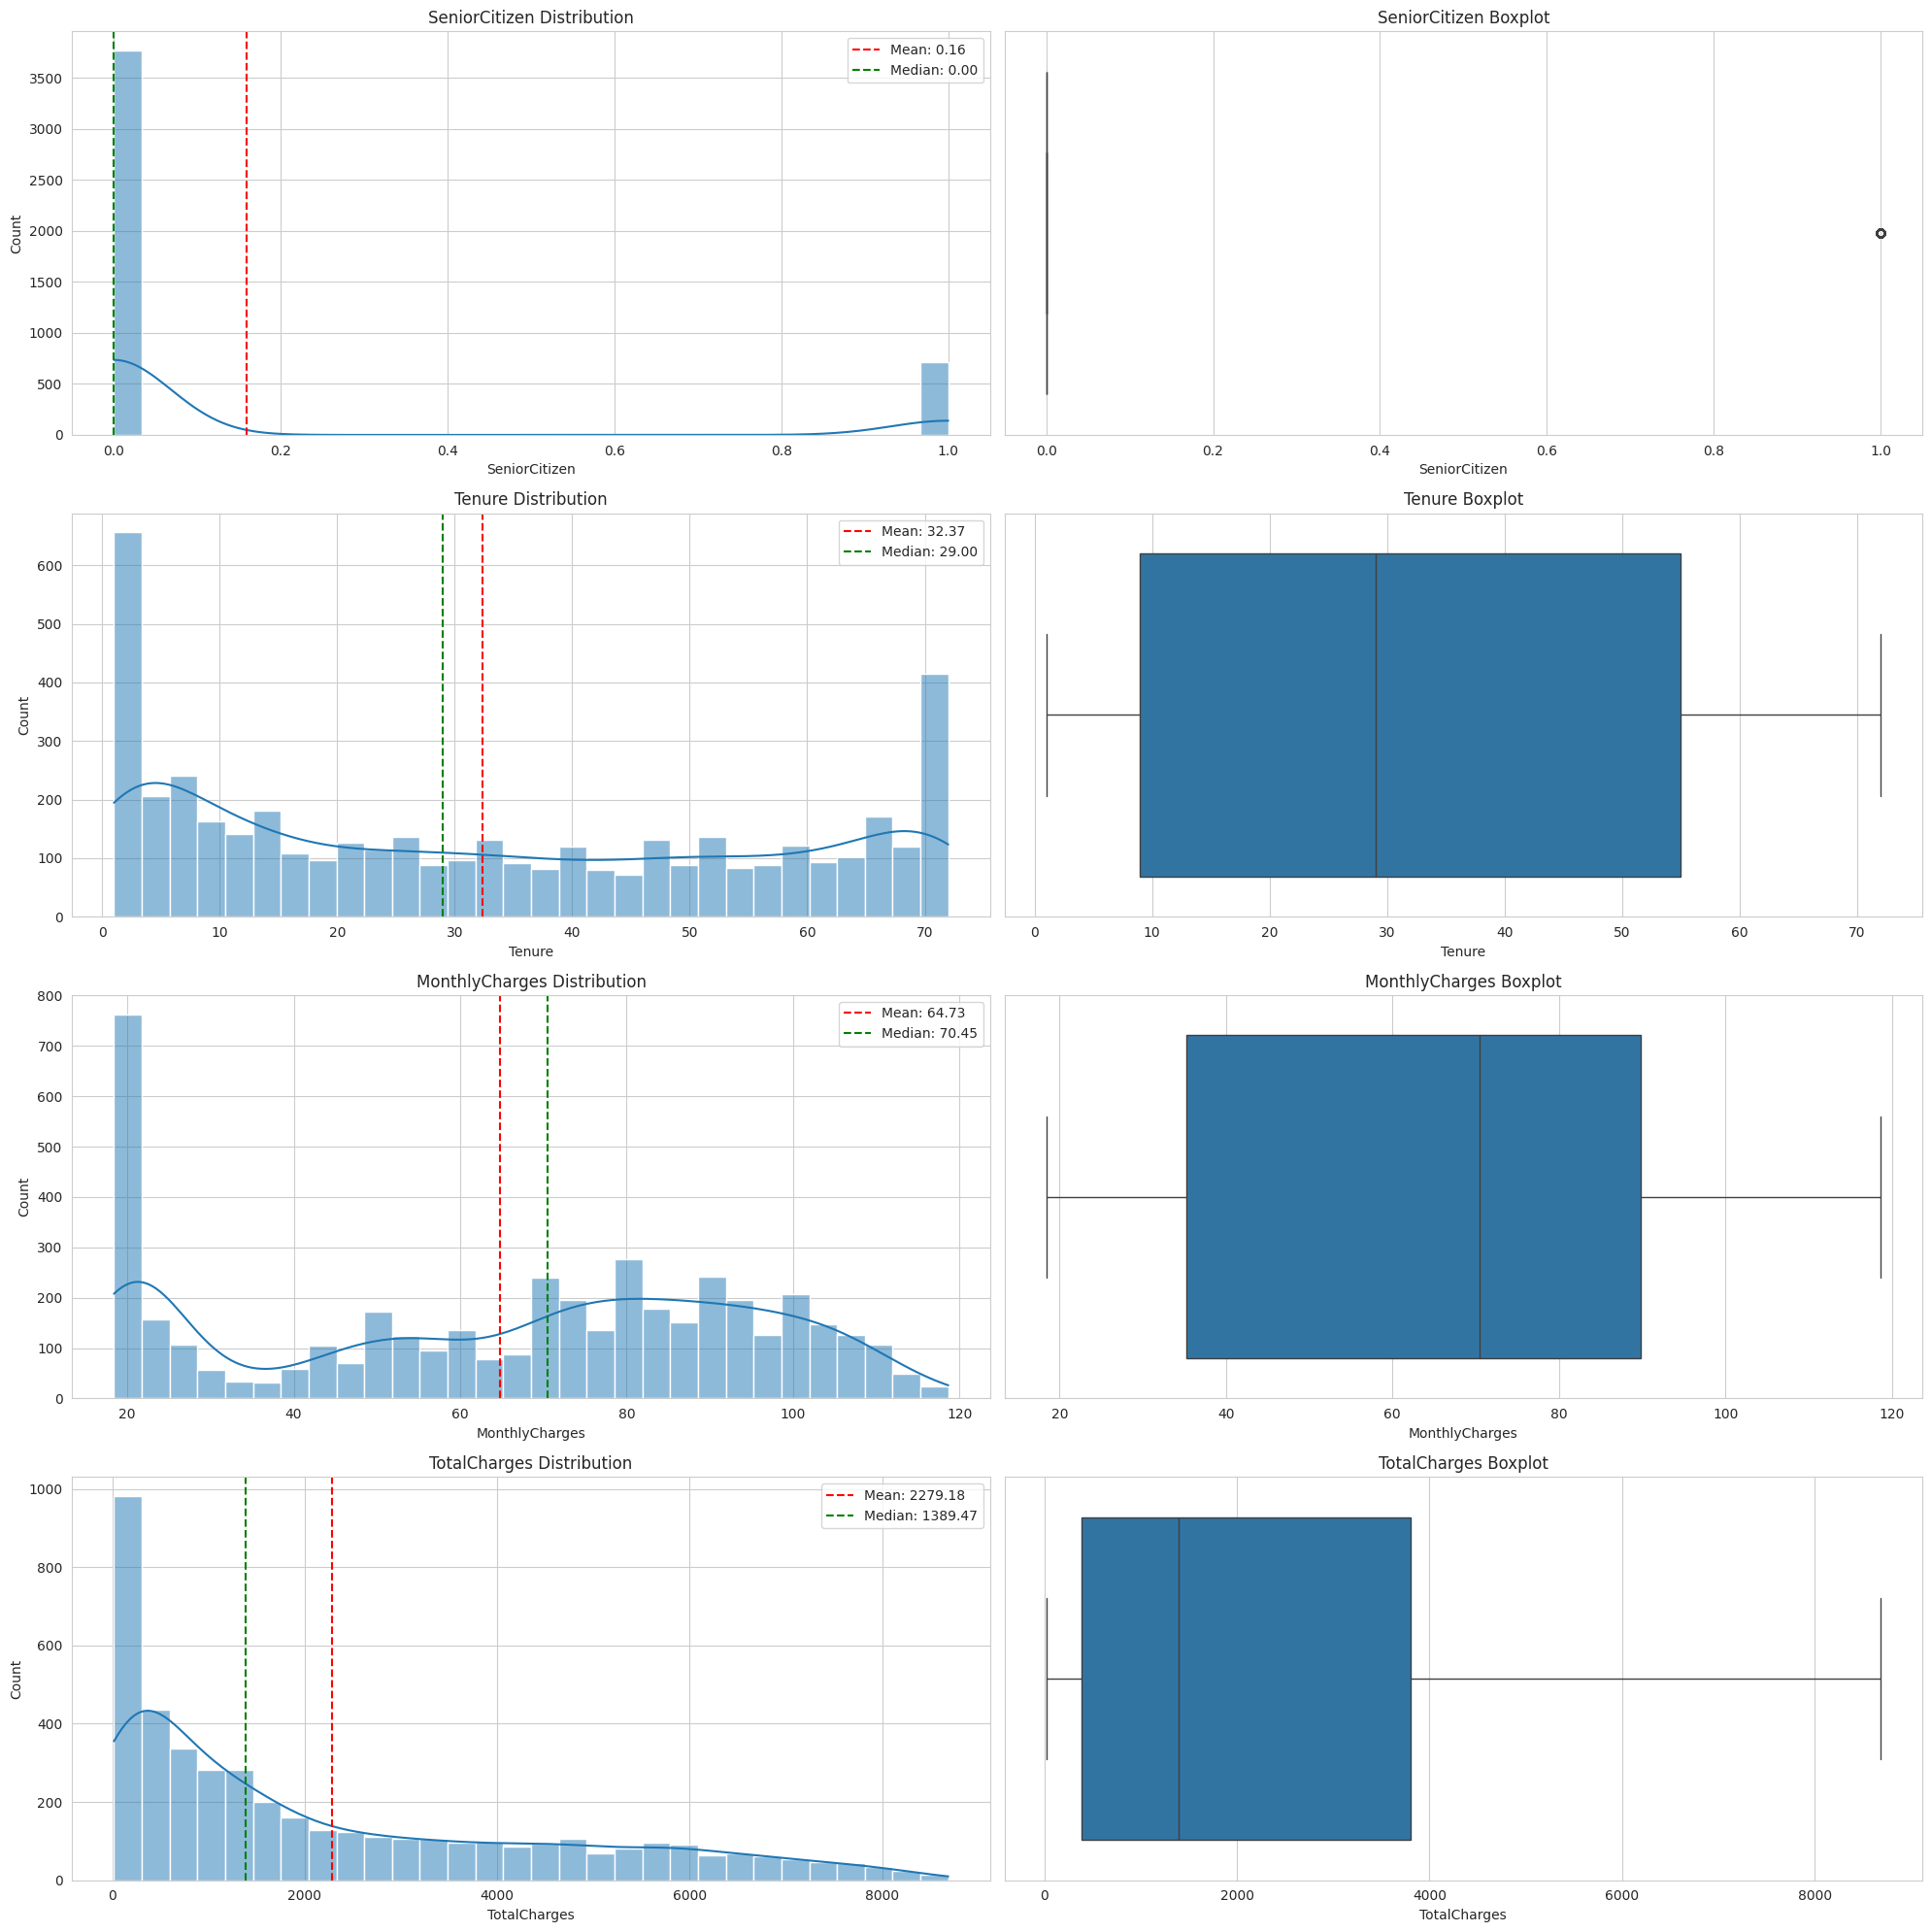

In [ ]:
print("="*60)
print(" VARIABLES DISTRIBUTION ANALYSIS (NUMERICAL FEATURES)")
print("="*60)

# Mengambil hanya kolom numerik (kecuali target)
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Churn', errors='ignore')

plt.figure(figsize=(20, 5 * len(num_cols)))

for i, col in enumerate(num_cols):

    # Histogram
    plt.subplot(len(num_cols), 2, 2*i + 1)
    sns.histplot(df_train[col], kde=True, bins=30)

    mean = df_train[col].mean()
    median = df_train[col].median()

    plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='green', linestyle='--', label=f'Median: {median:.2f}')

    plt.title(f'{col} Distribution')
    plt.legend()

    # Boxplot
    plt.subplot(len(num_cols), 2, 2*i + 2)
    sns.boxplot(x=df_train[col])
    plt.title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

## Numeric Features vs Target

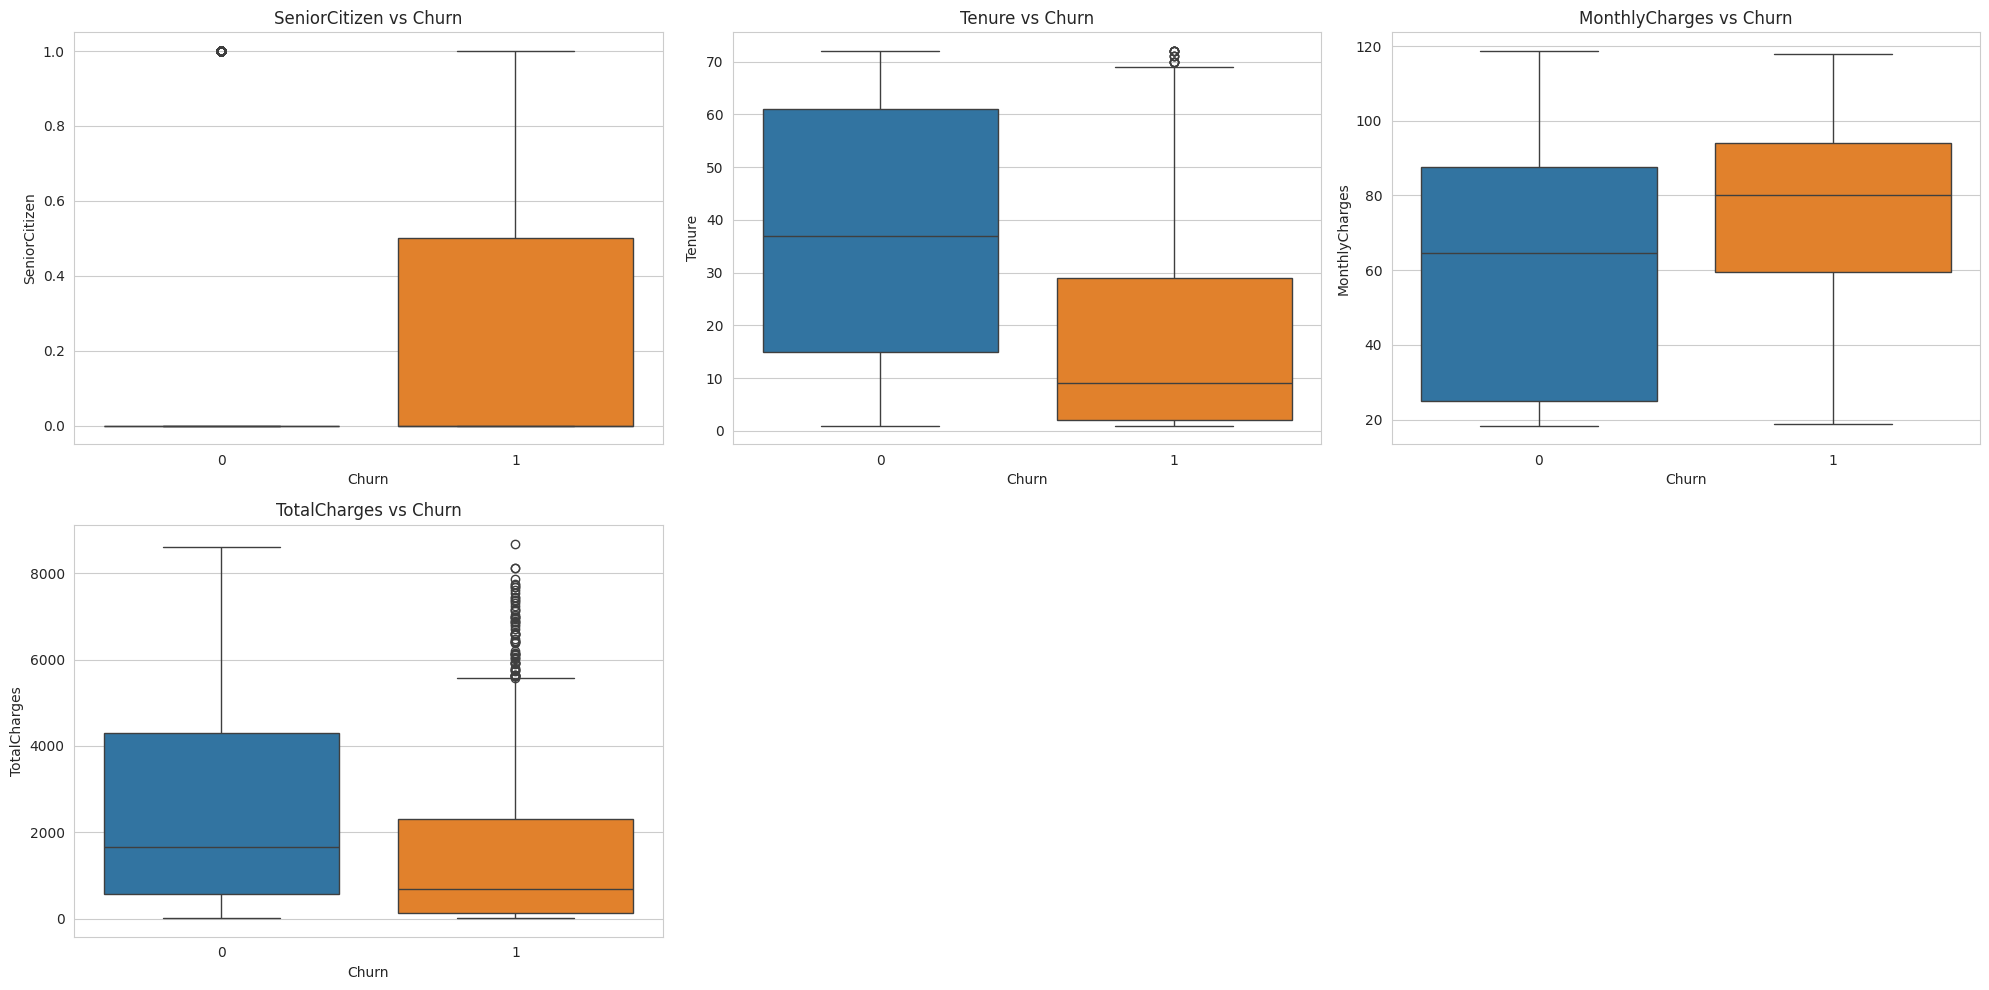

In [ ]:
x_train_numeric = df_train.select_dtypes(include=['int64', 'float64']).drop(columns='Churn', errors='ignore')

custom_palette = ['#1f77b4', '#ff7f0e']

n_cols = 3
n_rows = math.ceil(len(x_train_numeric.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(x_train_numeric.columns):
    sns.boxplot(
        x=df_train['Churn'],
        y=x_train_numeric[col],
        hue=df_train['Churn'],
        palette=custom_palette,
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Categorical Features vs Target

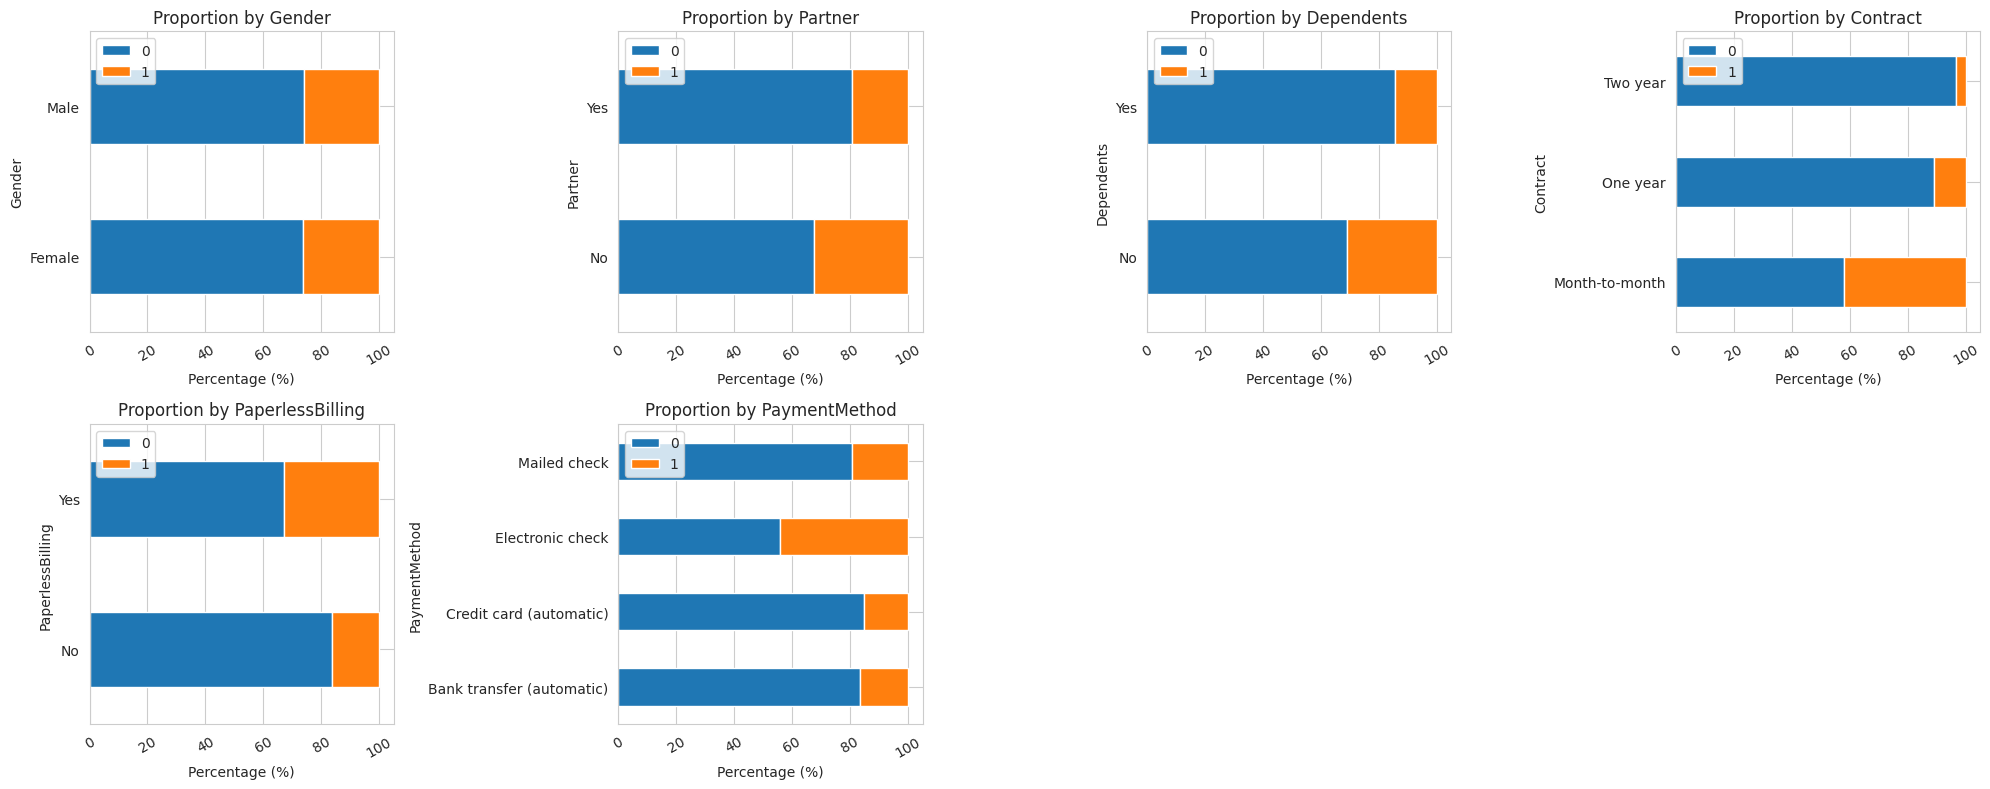

In [ ]:
cat_features = X_churn_train.select_dtypes(include=['object']).columns

n_cols = 4
n_rows = math.ceil(len(cat_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    crosstab = pd.crosstab(df_train[col], df_train['Churn'], normalize='index') * 100

    ax = crosstab.plot(
        kind='barh',
        stacked=True,
        color=['#1f77b4', '#ff7f0e'],
        ax=axes[i]
    )

    axes[i].set_title(f"Proportion by {col}")
    axes[i].set_ylabel(col)
    axes[i].set_xlabel("Percentage (%)")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(loc='upper left')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **3.	Analisis Korelasi dan Seleksi Fitur**

In [ ]:
# calculate VIF scores
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

# Mengambil fitur numerik dari TRAIN
X_train_numeric = X_churn_train.select_dtypes(include=['int64', 'float64'])

# Menambah constant untuk perhitungan VIF
X_vif = add_constant(X_train_numeric)

# Hitung VIF
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'vif_score': [
        vif(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Hapus konstanta
vif_df = vif_df[vif_df['feature'] != 'const']
vif_df.sort_values(by='vif_score', ascending=False)

,feature,vif_score
4,TotalCharges,9.379
2,Tenure,5.757
3,MonthlyCharges,3.258
1,SeniorCitizen,1.054


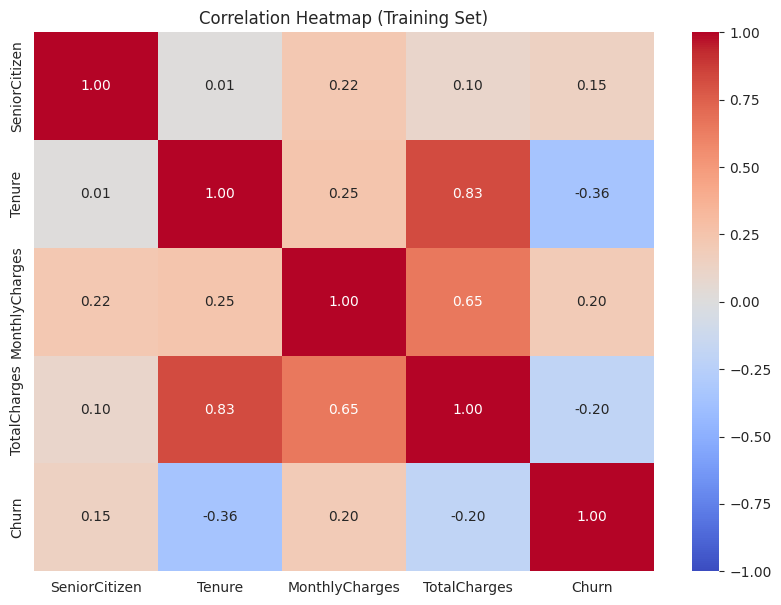

In [ ]:
# heatmap correlation

# menggabungkan X dan y TRAIN (untuk korelasi)
df_corr = pd.concat([X_churn_train, y_churn_train], axis=1)

corr_matrix = df_corr.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,   # batas bawah korelasi
    vmax=1    # batas atas korelasi
)
plt.title('Correlation Heatmap (Training Set)')
plt.show()



Berdasarkan hasil analisis *multicollinearity* menggunakan Variance Inflation Factor (VIF) dan correlation matrix, fitur `TotalCharges` menunjukkan tingkat multicollinearity tertinggi serta korelasi yang sangat kuat dengan `Tenure`. Oleh karena itu, `TotalCharges` dihapus untuk mengurangi redundansi informasi dan meningkatkan stabilitas model.

In [ ]:
# Drop Feature berdasarkan hasil VIF & correlation

cols_to_drop = ['TotalCharges']

X_churn_train_fs = X_churn_train.drop(columns=cols_to_drop)
X_churn_validation_fs = X_churn_validation.drop(columns=cols_to_drop)
X_churn_test_fs = X_churn_test.drop(columns=cols_to_drop)


In [ ]:
# Mengambil fitur numerik dari TRAIN setelah drop
X_train_numeric_fs = X_churn_train_fs.select_dtypes(include=['int64', 'float64'])

# Menambahkan konstanta
X_vif_fs = add_constant(X_train_numeric_fs)

# Hitung VIF ulang
vif_df_fs = pd.DataFrame({
    'feature': X_vif_fs.columns,
    'vif_score': [
        vif(X_vif_fs.values, i)
        for i in range(X_vif_fs.shape[1])
    ]
})

# Hapus konstanta
vif_df_fs = vif_df_fs[vif_df_fs['feature'] != 'const']

vif_df_fs.sort_values(by='vif_score', ascending=False)

,feature,vif_score
3,MonthlyCharges,1.123
2,Tenure,1.069
1,SeniorCitizen,1.053


Setelah menghapus fitur `TotalCharges`, perhitungan ulang Variance Inflation Factor (VIF) menunjukkan bahwa seluruh fitur numerik memiliki nilai VIF di bawah ambang batas, sehingga tidak ditemukan lagi indikasi multicollinearity yang signifikan.

# **4.	Pengolahan Data Kategorikal**

## Feature Engineering

In [ ]:
# Dataset setelah feature selection
X_churn_train_fs.head()


,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
customerID,,,,,,,,,
7542-CYDDM,Male,0.000,No,No,18.000,Month-to-month,No,Mailed check,20.050
4250-FDVOU,Female,0.000,No,No,6.000,Month-to-month,No,Electronic check,56.250
0617-FHSGK,Male,0.000,No,Yes,49.000,Month-to-month,No,Credit card (automatic),75.200
3982-DQLUS,Male,1.000,Yes,Yes,65.000,Month-to-month,Yes,Electronic check,85.750
0899-LIIBW,Male,0.000,Yes,No,34.000,Month-to-month,No,Electronic check,100.850


In [ ]:
# Identifikasi kolom numerik dan kategorikal

num_cols = X_churn_train_fs.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_churn_train_fs.select_dtypes(include='object').columns

print(f"  Kolom Numerik: {list(num_cols)}")
print(f"  Kolom Kategorikal: {list(cat_cols)}")


  Kolom Numerik: ['SeniorCitizen', 'Tenure', 'MonthlyCharges']
  Kolom Kategorikal: ['Gender', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Scaling

In [ ]:
scaler = StandardScaler()

# FIT hanya di TRAIN
X_train_scaled = scaler.fit_transform(X_churn_train_fs[num_cols])

# TRANSFORM validation & test
X_validation_scaled = scaler.transform(X_churn_validation_fs[num_cols])
X_test_scaled = scaler.transform(X_churn_test_fs[num_cols])

# Convert back to DataFrames with same columns and index
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=num_cols,
    index=X_churn_train_fs.index
)

X_validation_scaled = pd.DataFrame(
    X_validation_scaled,
    columns=num_cols,
    index=X_churn_validation_fs.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=num_cols,
    index=X_churn_test_fs.index
)

X_train_scaled.head()

,SeniorCitizen,Tenure,MonthlyCharges
customerID,,,
7542-CYDDM,-0.435,-0.586,-1.485
4250-FDVOU,-0.435,-1.075,-0.282
0617-FHSGK,-0.435,0.678,0.348
3982-DQLUS,2.297,1.330,0.699
0899-LIIBW,-0.435,0.066,1.200


### Encoding

In [ ]:
encoder = OneHotEncoder(
    sparse_output=False,
    drop='first',
    handle_unknown='ignore'
)

# FIT hanya di TRAIN
X_train_encoded = encoder.fit_transform(X_churn_train_fs[cat_cols])

# TRANSFORM validation & test
X_validation_encoded = encoder.transform(X_churn_validation_fs[cat_cols])
X_test_encoded = encoder.transform(X_churn_test_fs[cat_cols])

# Convert to DataFrame
encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_churn_train_fs.index
)

X_validation_encoded = pd.DataFrame(
    X_validation_encoded,
    columns=encoded_cols,
    index=X_churn_validation_fs.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_churn_test_fs.index
)

X_train_encoded.head()

,Gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,
7542-CYDDM,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
4250-FDVOU,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
0617-FHSGK,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000
3982-DQLUS,1.000,1.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000
0899-LIIBW,1.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000


### Combine Scaled and Encoded Data

In [ ]:
X_churn_train_final = pd.concat(
    [X_train_scaled, X_train_encoded],
    axis=1
)

X_churn_validation_final = pd.concat(
    [X_validation_scaled, X_validation_encoded],
    axis=1
)

X_churn_test_final = pd.concat(
    [X_test_scaled, X_test_encoded],
    axis=1
)

X_churn_train_final.head()

,SeniorCitizen,Tenure,MonthlyCharges,Gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,
7542-CYDDM,-0.435,-0.586,-1.485,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
4250-FDVOU,-0.435,-1.075,-0.282,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
0617-FHSGK,-0.435,0.678,0.348,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000
3982-DQLUS,2.297,1.330,0.699,1.000,1.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000
0899-LIIBW,-0.435,0.066,1.200,1.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000


### Handling Imbalance

In [ ]:
y_churn_train.value_counts(normalize = True)

,proportion
Churn,
0,0.739
1,0.261


Berdasarkan data diatas,

Berdasarkan data diatas, proporsi untuk kelas adalah (0: 74% dan 1: 26%), maka dapat dikategorikan sebagai imbalance moderat. Dimana data imbalance namun tidak ekstrem.

In [ ]:
# Class-Imbalance Handling
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_churn_train_ros, y_churn_train_ros = ros.fit_resample(
    X_churn_train_final,
    y_churn_train
)


y_churn_train_ros.value_counts(normalize=True)


,proportion
Churn,
0,0.500
1,0.500


Setelah dilakukan class-imbalance handdling, training set saat ini sudah seimbang.

# **5.	Pemilihan Metrik Evaluasi**

## **5.1 Jenis Masalah dan Karakteristik Dataset**

Permasalahan customer churn prediction merupakan binary classification problem, di mana target Churn memiliki dua kelas:

- 0 = Non-churn

- 1 = Churn

Berdasarkan analisis distribusi target pada training set, dataset menunjukkan ketidakseimbangan kelas moderat (moderate imbalance), dengan proporsi sekitar 74% non-churn dan 26% churn. Dalam konteks bisnis, kesalahan dalam memprediksi pelanggan yang sebenarnya akan churn (False Negative), memiliki dampak yang lebih besar dibandingkan kesalahan memprediksi pelanggan non-churn.

Oleh karena itu, penggunaan metrik evaluasi **tidak dapat hanya mengandalkan accuracy**, karena accuracy cenderung bias terhadap kelas mayoritas.

## **5.2 Pemilihan Metrik Evaluasi**

**1. Recall (Metrik Utama)**

Recall untuk analisis kelas churn (1) dipilih sebagai metrik utama, karena Recall mengukur kemampuan model dalam menemukan pelanggan yang benar-benar churn dan bagus untuk memprediksi False Negative.

Dalam konteks bisnis churn, semakin tinggi recall, semakin sedikit pelanggan churn yang terlewat.


**2. Precision (Metrik Pendukung)**

Precision digunakan sebagai metrik pendukung untuk memastikan bahwa prediksi churn yang dihasilkan model tidak terlalu banyak menghasilkan false positive. Precision digunakan untuk:

- Mengontrol biaya intervensi

- Menghindari terlalu banyak pelanggan non-churn yang salah ditargetkan

**3. F1-Score (Metrik Keseimbangan)**

Pada prakteknya, F1-Score digunakan untuk:

- Mengukur keseimbangan antara Recall dan Precision

- Memberikan gambaran performa model secara keseluruhan pada kelas churn


# **6.	Pelatihan Model dan Hyperparameter Tuning**

## Model Fitting

In [ ]:
# Memastikan target bukan column vector
y_churn_train_ros = y_churn_train_ros.squeeze()
y_churn_validation = y_churn_validation.squeeze()
y_churn_test = y_churn_test.squeeze()


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

# Custom function to display model evaluation metrics

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd

def evaluate_model(true, prediction, label=None):
    return pd.DataFrame({
        'Dataset': [label],
        'Accuracy (%)': [accuracy_score(true, prediction) * 100],
        'Recall': [recall_score(true, prediction, pos_label=1)],
        'Precision': [precision_score(true, prediction, pos_label=1)],
        'F1-Score': [f1_score(true, prediction, pos_label=1)]
    })



Untuk menentukan model yang dipilih, dilakukan perbandingan menggunakan 3 model berbeda. Antara lain:
- Logistic Regression
- KNN
- Random Forest

Dimana selanjutnya dapat ditentukan model mana yang menghasilkan hasil terbaik.

## 6.1 Logistic Regression

### Hyperparameter Grid

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'penalty': ['l2']
}

model_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    scoring='recall',
    cv=10
)

model_lr.fit(X_churn_train_ros, y_churn_train_ros)

print("Best Parameters:", model_lr.best_params_)
print("Best Recall (CV):", model_lr.best_score_)



Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Recall (CV): 0.7969120205071867


### Model Evaluation

In [ ]:
pred_lr_train = model_lr.predict(X_churn_train_ros)
pred_lr_val = model_lr.predict(X_churn_validation_final)

pd.concat([
    evaluate_model(y_churn_train_ros, pred_lr_train, "Train"),
    evaluate_model(y_churn_validation, pred_lr_val, "Validation")
])


,Dataset,Accuracy (%),Recall,Precision,F1-Score
0,Train,76.564,0.801,0.748,0.774
0,Validation,72.946,0.786,0.524,0.629


## 6.2 K-Nearest Neighbors (KNN)

### Hyperparameter Grid

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
param_grid_knn = {
    'n_neighbors': [7, 9, 11, 25, 51, 75, 99],
    'p': [1, 2]
}

model_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='recall',
    cv=10
)

model_knn.fit(X_churn_train_ros, y_churn_train_ros)

print("Best Parameters:", model_knn.best_params_)
print("Best Recall (CV):", model_knn.best_score_)



Best Parameters: {'n_neighbors': 7, 'p': 2}
Best Recall (CV): 0.8540474228691751


### Model Evaluation

In [ ]:
pred_knn_train = model_knn.predict(X_churn_train_ros)
pred_knn_val = model_knn.predict(X_churn_validation_final)

pd.concat([
    evaluate_model(y_churn_train_ros, pred_knn_train, "Train"),
    evaluate_model(y_churn_validation, pred_knn_val, "Validation")
])


,Dataset,Accuracy (%),Recall,Precision,F1-Score
0,Train,82.759,0.902,0.785,0.840
0,Validation,68.214,0.706,0.470,0.565


## 6.3 Random Forest


### Hyperparameter Grid

In [ ]:
from sklearn.ensemble import RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
model_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='recall',
    cv=10
)

model_rf.fit(X_churn_train_ros, y_churn_train_ros)

print("Best Parameters:", model_rf.best_params_)
print("Best Recall (CV):", model_rf.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Recall (CV): 0.9685800604229607


### Model Evaluation

In [ ]:
pred_rf_train = model_rf.predict(X_churn_train_ros)
pred_rf_val = model_rf.predict(X_churn_validation_final)

pd.concat([
    evaluate_model(y_churn_train_ros, pred_rf_train, "Train"),
    evaluate_model(y_churn_validation, pred_rf_val, "Validation")
])


,Dataset,Accuracy (%),Recall,Precision,F1-Score
0,Train,99.879,1.000,0.998,0.999
0,Validation,74.107,0.554,0.557,0.555


## 6.4 Performa Model

In [ ]:
# Prediksi Validation Set

# Logistic Regression
pred_lr_val = model_lr.predict(X_churn_validation_final)

# KNN
pred_knn_val = model_knn.predict(X_churn_validation_final)

# Random Forest
pred_rf_val = model_rf.predict(X_churn_validation_final)


In [ ]:
# Evaluasi tiap model

eval_lr = evaluate_model(
    y_churn_validation,
    pred_lr_val,
    label='Logistic Regression'
)

eval_knn = evaluate_model(
    y_churn_validation,
    pred_knn_val,
    label='KNN'
)

eval_rf = evaluate_model(
    y_churn_validation,
    pred_rf_val,
    label='Random Forest'
)

comparison_table = pd.concat(
    [eval_lr, eval_knn, eval_rf],
    axis=0
).reset_index(drop=True)

comparison_table

comparison_table.sort_values(
    by='Recall',
    ascending=False
)


,Dataset,Accuracy (%),Recall,Precision,F1-Score
0,Logistic Regression,72.946,0.786,0.524,0.629
1,KNN,68.214,0.706,0.470,0.565
2,Random Forest,74.107,0.554,0.557,0.555


Berdasarkan hasil diatas, dapat disimpulkan bahwa:

1. **Logistic Regression** menghasilkan recall tertinggi, sehingga paling efektif dalam mendeteksi pelanggan churn.

2. **KNN** memiliki performa recall yang cukup baik, namun masih lebih rendah dibandingkan Logistic Regression.

3. **Random Forest** menunjukkan accuracy tertinggi, tetapi recall lebih rendah, sehingga kurang optimal untuk tujuan utama mendeteksi churn.

Oleh karena itu, berdasarkan tujuan bisnis untuk meminimalkan pelanggan churn yang terlewat, **Logistic Regression dipilih sebagai model terbaik** pada tahap ini dan digunakan untuk evaluasi akhir pada test set.

# **7.	Evaluasi Model**

Berdasarkan hasil perbandingan performa pada validation set, **Logistic Regression Model** dipilih sebagai model terbaik, karena:

- Memiliki nilai recall tertinggi

- Lebih efektif dalam mendeteksi pelanggan churn

- Sejalan dengan tujuan bisnis untuk meminimalkan churn yang terlewat (False Negative)

Model ini selanjutnya dievaluasi pada test set untuk mengukur performa akhir.

In [ ]:
pred_lr_train = model_lr.predict(X_churn_train_ros)
pred_lr_val = model_lr.predict(X_churn_validation_final)

pd.concat([
    evaluate_model(y_churn_train_ros, pred_lr_train, "Train"),
    evaluate_model(y_churn_validation, pred_lr_val, "Validation")
])


,Dataset,Accuracy (%),Recall,Precision,F1-Score
0,Train,76.564,0.801,0.748,0.774
0,Validation,72.946,0.786,0.524,0.629


## Evaluasi pada Test Set

In [ ]:
#Prediksi Test Set

# Prediksi menggunakan model terbaik (Logistic Regression)
y_test_pred = model_lr.predict(X_churn_test_final)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_churn_test, y_test_pred))

evaluate_model(
    y_churn_test,
    y_test_pred,
    label='Test'
)



              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1044
           1       0.51      0.79      0.62       357

    accuracy                           0.75      1401
   macro avg       0.71      0.76      0.72      1401
weighted avg       0.81      0.75      0.77      1401



,Dataset,Accuracy (%),Recall,Precision,F1-Score
0,Test,75.232,0.787,0.509,0.618


Berdasarkan hasil analisis diatas, 78.7% pelanggan churn berhasil ditangkap model. Pada dataset Train dan Validation, selisih recall kecil sehingga tidak overfitting). Sedangkan perbandingan recall antara dataset validation dan test cenderung identik.

## Confusion Matrix

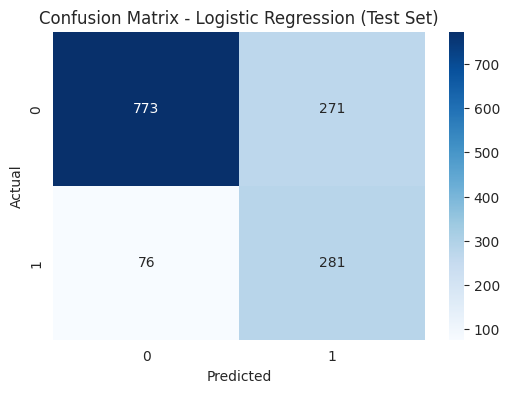

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_churn_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Test Set)')
plt.show()


Berdasarkan hasil visualisasi diatas False Negatif sebanyak 76 dari total 357 yang mana merupakan nilai yang cukup rendah.

# **Kesimpulan**

Berdasarkan Model Logistic Regression, performa yang dimiliki kasus ini cukup konsisten antara training, validation, dan test set. Dimana, nilai recall churn yang stabil (~0.79) menunjukkan bahwa model mampu mendeteksi sebagian besar pelanggan yang berpotensi churn. Meskipun precision churn relatif lebih rendah, hal ini merupakan trade-off yang dapat diterima karena tujuan utama bisnis adalah meminimalkan pelanggan churn yang terlewat.

Untuk tujuan churn prediction, model ini sudah cukup optimal karena mampu menangkap hampir 80% pelanggan churn dengan generalisasi yang baik di data test.